In [43]:
# @title GPU resource check
!nvidia-smi

Tue Jun 24 09:40:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             49W /  400W |    6213MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Checks for GPU Resources within Google Colab.

In [44]:
# @title Plotly Installation
! pip install plotly -q

Using Plotly for 3D Visualizations

In [45]:
# @title Git clone of Point-E
!git clone https://github.com/openai/point-e

Cloning into 'point-e'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 57 (delta 4), reused 2 (delta 2), pack-reused 27 (from 1)
Receiving objects: 100% (57/57), 1.57 MiB | 44.56 MiB/s, done.
Resolving deltas: 100% (7/7), done.


Clones the Github Respiratory for Point-E

In [46]:
# @title Change of Current Directory
%cd point-e

/content/point-e/point-e/point-e


Switches the working directory to the cloned Point-E repository allowing Python code to directly access modules.

In [47]:
# @title Installation of Point-E
! pip install -e .

Obtaining file:///content/point-e/point-e/point-e
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-install-gl9n8kv8/clip_4f2f225a46f7482f903c91f76c76b2dd
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-install-gl9n8kv8/clip_4f2f225a46f7482f903c91f76c76b2dd
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Attempting uninstall: point-e
    Found existing installation: point-e 0.0.0
    Uninstalling point-e-0.0.0:
      Successfully uninstalled point-e-0.0.0
  Running setup.py develop for point-e


Point-E Package Locally Installed

In [48]:
# @title Library Importation
import torch
from tqdm.auto import tqdm

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

Importing Libraries Pytorch & Point-e

In [49]:
# @title Creation of Base Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('creating base model...')
base_name = 'base40M-textvec'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval()
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

print('creating upsample model...')
upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])

print('downloading base checkpoint...')
base_model.load_state_dict(load_checkpoint(base_name, device))

print('downloading upsampler checkpoint...')
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

creating base model...
creating upsample model...
downloading base checkpoint...
downloading upsampler checkpoint...


<All keys matched successfully>

Firstly loads the base Point-E model and the upsampler model as well as downloading the pretrained weights so checkpoints. Secondly initializes them for generation. Acting as neural networks that will turn your prompt or image into a 3D point cloud.

In [50]:
# @title Sampler
sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 0.0],
    model_kwargs_key_filter=('texts', ''), # Do not condition the upsampler at all
)

Defines a sampler object which combines both the base model and upsampler whilst setting parameters like our number of steps and guidance scale as well as acting as our main tool for generating point clouds.

In [60]:
# @title Prompt
# Set a prompt to condition on.
prompt = 'An Apple'

# Produce a sample from the model.
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt]))):
    samples = x

0it [00:00, ?it/s]

Triggers the sampler to generate a point cloud object using a text prompt

In [61]:
# @title Sampler Output
pc = sampler.output_to_point_clouds(samples)[0]

Cell saves or stores the generated point cloud sample from the sampler from the sample_batch(...) call. In addition what is present is a list/array of generated samples containing 3D point data with RGB color information.

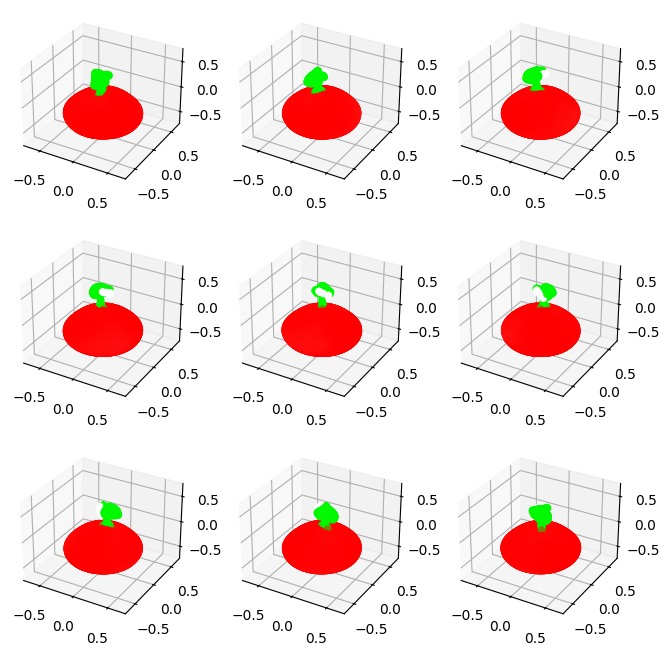

In [62]:
# @title Point Cloud Plot
fig = plot_point_cloud(pc, grid_size=3, fixed_bounds=((-0.75, -0.75, -0.75),(0.75, 0.75, 0.75)))

Displays the 3D point clouds using Plotly, by looping through all the outputs and inspecting if the model interpreted the prompt/image well.

In [63]:
# @title Graphical Plot
import plotly.graph_objects as go

Imports Plotly’s 3D graphing tools into the workflow.

In [64]:
# @title Graphical Plot Computation
fig_plotly = go.Figure(
        data=[
            go.Scatter3d(
                x=pc.coords[:,0], y=pc.coords[:,1], z=pc.coords[:,2],
                mode='markers',
                marker=dict(
                  size=2,
                  color=['rgb({},{},{})'.format(r,g,b) for r,g,b in zip(pc.channels["R"], pc.channels["G"], pc.channels["B"])],
              )
            )
        ],
        layout=dict(
            scene=dict(
                xaxis=dict(visible=False),
                yaxis=dict(visible=False),
                zaxis=dict(visible=False)
            )
        ),
    )

This Block prepares the 3D point cloud data into a format that Plotly can understand as well as organizing the XYZ coordinates and optional RGB colors for 3D plotting and further customizing the size, color scale, transparency and lighting.

In [65]:
# @title Plot Presented
fig_plotly.show(renderer="colab")

Displays the figure (fig.show()) inline in Colab as an interactive 3D plot in the format of a clean, colored point cloud representation.

In [57]:
# @title Open3D Installation
!pip install open3d # Install the open3d library
import open3d as o3d

# Assuming you have the 3D point cloud as a numpy array, convert it to a mesh
# Example: If you already have vertices for the apple, stem, etc., use them to create a mesh
# Combine the apple, stem, and leaf into a single mesh
apple_mesh = o3d.geometry.TriangleMesh.create_sphere(radius=1.0)
apple_mesh.paint_uniform_color([1.0, 0.0, 0.0])  # Red apple color

stem_mesh = o3d.geometry.TriangleMesh.create_cylinder(radius=0.1, height=0.5)
stem_mesh.paint_uniform_color([0.0, 1.0, 0.0])  # Green stem
stem_mesh.translate([0, 0, 1.0])  # Position the stem on top of the apple

# Combine the meshes into a single mesh
combined_mesh = apple_mesh + stem_mesh

# Save the combined mesh as an OBJ file
o3d.io.write_triangle_mesh("apple_with_stem.obj", combined_mesh)
print("Model saved as 'apple_with_stem.obj'")

Model saved as 'apple_with_stem.obj'


Installs the open3d library and its dependencies for further visualization.

In [66]:
# @title OBJ Computation
from google.colab import files
import open3d as o3d

# Assuming you have the 3D point cloud as a numpy array, convert it to a mesh
# Example: If you already have vertices for the apple, stem, etc., use them to create a mesh
# Combine the apple, stem, and leaf into a single mesh
apple_mesh = o3d.geometry.TriangleMesh.create_sphere(radius=1.0)
apple_mesh.paint_uniform_color([1.0, 0.0, 0.0])  # Red apple color

stem_mesh = o3d.geometry.TriangleMesh.create_cylinder(radius=0.1, height=0.5)
stem_mesh.paint_uniform_color([0.0, 1.0, 0.0])  # Green stem
stem_mesh.translate([0, 0, 1.0])  # Position the stem on top of the apple

# Combine the meshes into a single mesh
combined_mesh = apple_mesh + stem_mesh

# Save the combined mesh as an OBJ file
o3d.io.write_triangle_mesh("apple_with_stem.obj", combined_mesh)
print("Model saved as 'apple_with_stem.obj'")

# Download the saved OBJ file immediately after creation
files.download("apple_with_stem.obj")

Model saved as 'apple_with_stem.obj'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Converts the Point Cloud into an obj Object file format storing vertices, faces, normals and texture coordinates.